# Exploratory Data Analysis

## Libraries

In [1]:
from pathlib import Path
import os

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Declarations

In [3]:
FOLDER_NAME = "parquet"

### Parquet Processor

In [4]:
def process_parquet_files(parquet_folder, process_func, *args, **kwargs):
    parquet_files = sorted(Path(parquet_folder).glob("*.parquet"))

    if not parquet_files:
        raise FileNotFoundError("No Parquet files found.")

    results = []

    total = len(parquet_files)

    for i, file in enumerate(parquet_files, start=1):
        print(f"Processing [{i}/{total}] {file.name}...", end="\r", flush=True)

        df = pd.read_parquet(file)

        result = process_func(df, *args, **kwargs)
        results.append(result)

    print(" " * 100, end="\r")
    print(f"Finished processing all files: {process_func.__name__}")
    return results

In [5]:
def sample_parquet_files(folder_name, sample_frac=None, random_state=42):
    parquet_files = sorted(
        f for f in os.listdir(folder_name)
        if f.endswith(".parquet")
    )

    total = len(parquet_files)
    dfs = []

    for i, file in enumerate(parquet_files, start=1):
        print(f"Processing [{i}/{total}] {file}...", end="\r", flush=True)
        path = os.path.join(folder_name, file)
        df = pd.read_parquet(path)

        df = (
            df.select_dtypes(include=np.number)
              .replace([np.inf, -np.inf], np.nan)
        )

        if sample_frac is not None:
            df = df.sample(
                frac=sample_frac,
                random_state=random_state
            )

        dfs.append(df)
    print("Finished retrieving samples from all files.")
    return pd.concat(dfs, ignore_index=True)

## Count Total Rows

In [6]:
def count_total_rows(df:pd.DataFrame):
    return len(df)

In [7]:
def analyze_total_rows(folder_name:str):
    return sum(process_parquet_files(folder_name, count_total_rows))

In [8]:
TOTAL_ROWS = analyze_total_rows(FOLDER_NAME)
print(f"Total rows: {TOTAL_ROWS}")

Finished processing all files: count_total_rows                                                     
Total rows: 16233002


## Missing Values

In [9]:
def count_missing_values(df: pd.DataFrame):
    return df.isna().sum()

In [10]:
def analyze_missing_values(folder_name: str) -> pd.DataFrame:
    missing_values = (
        pd.concat(
            process_parquet_files(folder_name, count_missing_values),
            axis=1
        )
        .fillna(0)
        .sum(axis=1)
        .to_frame(name="Missing Count")
        .sort_values(by="Missing Count", ascending=False)
    )

    missing_values["Missing Percentage"] = (
        missing_values["Missing Count"] / TOTAL_ROWS * 100
    ).round(4)

    return missing_values

In [11]:
missing_values = analyze_missing_values(FOLDER_NAME)
missing_values.head()

Finished processing all files: count_missing_values                                                 


,Missing Count,Missing Percentage
Flow Byts/s,59721.0,0.3679
Dst Port,0.0,0.0000
Timestamp,0.0,0.0000
Protocol,0.0,0.0000
Flow Duration,0.0,0.0000


## Class Distribution

In [12]:
def count_class_distribution(df: pd.DataFrame) -> pd.Series:
    return df["Label"].value_counts()

In [13]:
def analyze_class_distribution(folder_name: str) -> pd.DataFrame:
    results = process_parquet_files(folder_name, count_class_distribution)

    class_counts = pd.concat(results, axis=1).fillna(0).sum(axis=1)

    class_distribution = (
        class_counts
        .to_frame(name="Count")
        .sort_values("Count", ascending=False)
    )

    class_distribution["Percentage"] = (
        class_distribution["Count"] / class_distribution["Count"].sum() * 100
    ).round(4)

    return class_distribution

In [14]:
distribution = analyze_class_distribution(FOLDER_NAME)
distribution.head()

Finished processing all files: count_class_distribution                                             


,Count,Percentage
Label,,
Benign,13484708.0,83.0697
DDOS attack-HOIC,686012.0,4.2260
DDoS attacks-LOIC-HTTP,576191.0,3.5495
DoS attacks-Hulk,461912.0,2.8455
Bot,286191.0,1.7630


In [15]:
def plot_class_distribution_bar(
    class_distribution,
    count_col="Count",
    percentage_col="Percentage",
    figsize=(12, 8)
):
    df = class_distribution.sort_values(count_col, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.barh(
        df.index,
        df[count_col]
    )

    for bar, pct, cnt in zip(bars, df[percentage_col], df[count_col]):
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height()/2,
            f"Percentage: {pct:.2f}%\nCount: {cnt}",
            va="center",
            fontsize=9
        )

    ax.set_title("Class Distribution")
    ax.set_xlabel("Number of Samples")
    ax.set_ylabel("Attack Type")

    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{int(x):,}")
    )
    plt.tight_layout()
    plt.show()

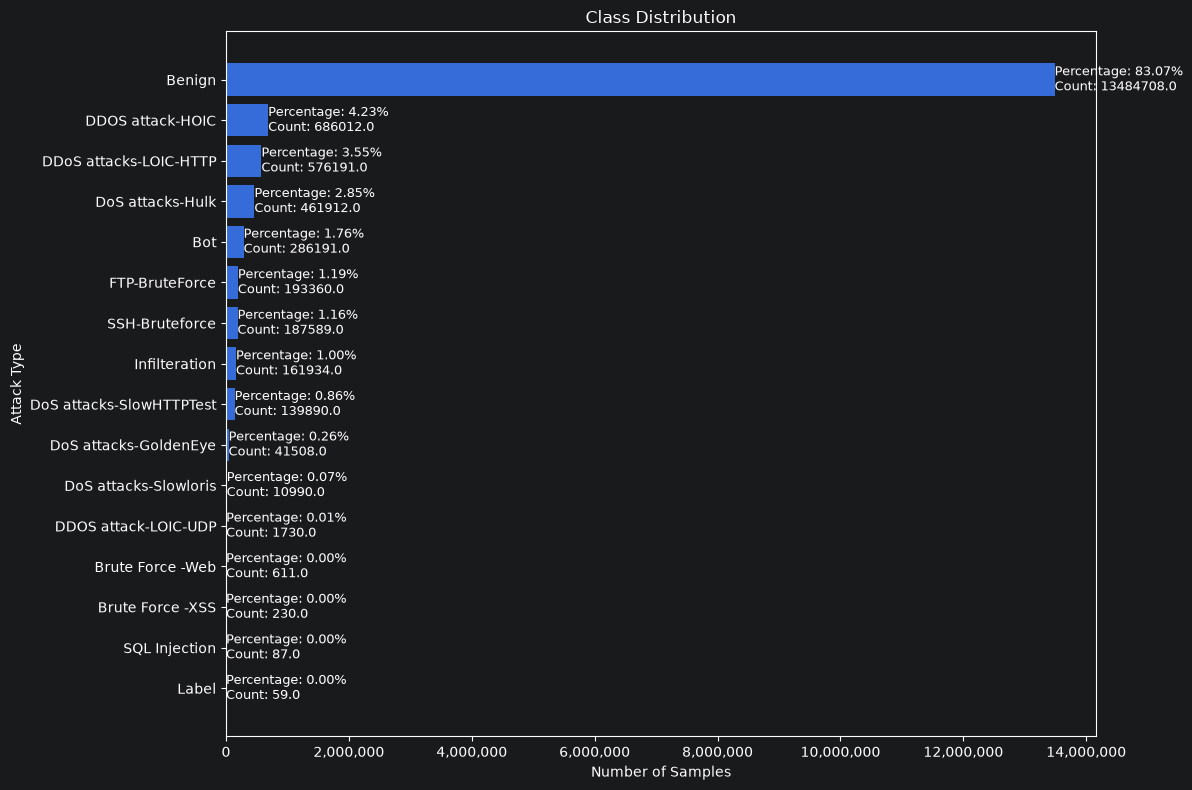

In [16]:
plot_class_distribution_bar(class_distribution=distribution)

### Duplicate Rows

In [17]:
def count_duplicate_row(df:pd.DataFrame):
    return df.duplicated().sum()

In [18]:
def analyze_duplicate_row(folder_name: str):
    duplicate_rows = process_parquet_files(folder_name, count_duplicate_row)
    return int(np.sum(duplicate_rows))

In [19]:
duplicate_rows = analyze_duplicate_row(FOLDER_NAME)
print(f"Duplicated rows: {duplicate_rows}")

Finished processing all files: count_duplicate_row                                                  
Duplicated rows: 383622


### Count Infinite Values

In [20]:
def count_inf_values(df):
    df = df.select_dtypes(include=np.number)
    return pd.Series(
        np.isinf(df).sum(axis=0),
        index=df.columns,
        name="Infinite Count"
    )

In [21]:
def analyze_inf_values(folder_name, total_rows):
    inf_counts = (
        pd.concat(
            process_parquet_files(folder_name, count_inf_values),
            axis=1
        )
        .fillna(0)
        .sum(axis=1)
        .astype(int)
        .to_frame(name="Infinite Count")
    )

    inf_counts["Infinite Percentage"] = (
        inf_counts["Infinite Count"] / total_rows * 100
    ).round(4)

    return inf_counts.sort_values(
        by=["Infinite Count", "Infinite Percentage"],
        ascending=[False, False]
    )

In [22]:
inf_values = analyze_inf_values(FOLDER_NAME, TOTAL_ROWS)
inf_values.head()

Finished processing all files: count_inf_values                                                     


,Infinite Count,Infinite Percentage
Flow Pkts/s,88428,0.5447
Flow Byts/s,33458,0.2061
Dst Port,0,0.0000
Protocol,0,0.0000
Flow Duration,0,0.0000


### Descriptive Statistics

In [23]:
def describe_chunk(df):
    df = (
        df.select_dtypes(include=np.number)
          .replace([np.inf, -np.inf], np.nan)
          .astype(np.float64)
    )
    return {
        "count": df.count(),
        "mean": df.mean(),
        "var": df.mean(),
        "std": df.mean(),
        "min": df.min(),
        "max": df.max(),
    }

In [24]:
def analyze_descriptive_statistics(folder_name):
    results = process_parquet_files(folder_name, describe_chunk)
    return results


In [25]:
stats = analyze_descriptive_statistics(FOLDER_NAME)
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(stats)

Finished processing all files: describe_chunk                                                       


[{'count': Dst Port             100000
  Protocol             100000
  Flow Duration        100000
  Tot Fwd Pkts         100000
  Tot Bwd Pkts         100000
  TotLen Fwd Pkts      100000
  TotLen Bwd Pkts      100000
  Fwd Pkt Len Max      100000
  Fwd Pkt Len Min      100000
  Fwd Pkt Len Mean     100000
  Fwd Pkt Len Std      100000
  Bwd Pkt Len Max      100000
  Bwd Pkt Len Min      100000
  Bwd Pkt Len Mean     100000
  Bwd Pkt Len Std      100000
  Flow Byts/s           99892
  Flow Pkts/s           99892
  Flow IAT Mean        100000
  Flow IAT Std         100000
  Flow IAT Max         100000
  Flow IAT Min         100000
  Fwd IAT Tot          100000
  Fwd IAT Mean         100000
  Fwd IAT Std          100000
  Fwd IAT Max          100000
  Fwd IAT Min          100000
  Bwd IAT Tot          100000
  Bwd IAT Mean         100000
  Bwd IAT Std          100000
  Bwd IAT Max          100000
  Bwd IAT Min          100000
  Fwd PSH Flags        100000
  Bwd PSH Flags        100000
 

### Feature's Correlation

> Retrieve from samples 10% from population

In [30]:
def feature_correlation(folder_name, sample_frac=None):
    df = sample_parquet_files(
        folder_name,
        sample_frac=sample_frac
    )
    print(f"Calculating Correlation for {len(df)} samples")
    corr = df.corr(numeric_only=True)

    return corr

In [31]:
corr = feature_correlation(
    FOLDER_NAME,0.1
)

Finished retrieving samples from all files.rafficForML_CICFlowMeter_00007.parquet...
Calculating Correlation for 1623303 samples


In [33]:
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(corr)

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Src Port
Dst Port,1.000000,-0.263415,-0.089373,-0.006611,-0.012111,-5.771697e-03,-0.008251,0.160921,-0.208061,0.106931,0.254179,-0.200372,-0.247019,-0.188809,-1.304507e-01,0.096781,0.158237,0.058856,-0.084068,-0.004538,0.068772,-0.085500,0.050648,-0.075097,0.000676,0.065055,-0.128593,-0.077341,-0.097715,-0.104664,-0.033693,0.109344,NaN,0.002815,NaN,-0.007253,-0.012088,0.201513,-0.027970,-0.228883,-0.059741,-0.110175,-0.034646,-0.025328,0.093283,0.109344,-0.003446,-0.181376,0.445757,0.353321,0.002815,-0.003444,-0.136026,-0.126407,0.106931,-0.188809,NaN,NaN,NaN,NaN,NaN,NaN,-0.006611,-5.771697e-03,-0.012111,-0.008251,0.206367,-0.006711,-0.006256,0.227016,-0.028297,-0.026561,-0.034008,-0.020953,0.017189,-0.031641,0.014457,0.020535,-0.816996
Protocol,-0.263415,1.000000,-0.257796,0.019094,-0.014790,1.707451e-02,-0.009881,-0.287835,0.774123,-0.062749,-0.337891,-0.278325,0.844655,-0.032745,-3.609476e-01,-0.013194,-0.103027,-0.172391,-0.143443,-0.225705,-0.156566,-0.253510,-0.180886,-0.145015,-0.220968,-0.156041,-0.157680,-0.094400,-0.135352,-0.135407,-0.034085,-0.118202,NaN,-0.004253,NaN,0.016004,-0.017954,-0.090856,-0.082433,0.828524,-0.309354,-0.068961,-0.297168,-0.182988,-0.038481,-0.118202,-0.267034,-0.449138,-0.391905,-0.115585,-0.004253,-0.267034,0.286925,0.022576,-0.062749,-0.032745,NaN,NaN,NaN,NaN,NaN,NaN,0.019094,1.707451e-02,-0.014790,-0.009881,-0.305630,-0.236609,0.020247,-0.707372,-0.085274,-0.075286,-0.094746,-0.064179,-0.197389,-0.048970,-0.198335,-0.194119,0.403014
Flow Duration,-0.089373,-0.257796,1.000000,0.046121,0.054077,4.659578e-02,0.042793,0.136472,-0.159079,-0.011920,0.075448,0.284831,-0.178495,0.245105,2.506185e-01,-0.029830,-0.077371,0.505910,0.574007,0.761305,0.442871,0.996238,0.555683,0.592477,0.758925,0.452289,0.808969,0.407805,0.599159,0.612707,0.135458,0.020083,NaN,-0.002961,NaN,0.050838,0.056891,-0.067222,-0.064415,-0.168316,0.265132,0.240365,0.257640,0.198524,-0.027121,0.020083,0.073322,0.138974,-0.013102,-0.072204,-0.002961,0.073320,-0.045066,0.202742,-0.011920,0.245105,NaN,NaN,NaN,NaN,NaN,NaN,0.046121,4.659578e-02,0.054077,0.042791,0.099258,-0.097293,0.043588,0.001757,0.170504,0.170942,0.210797,0.121153,0.731578,0.214581,0.739732,0.714383,-0.049094
Tot Fwd Pkts,-0.006611,0.019094,0.046121,1.000000,0.039185,9.871275e-01,0.038571,-0.004246,0.009937,-0.002642,-0.005957,-0.005004,-0.007478,-0.001972,-5.646036e-03,-0.000905,-0.002864,-0.003470,-0.002099,-0.002257,-0.003201,0.046118,-0.003592,-0.001774,-0.002613,-0.003251,0.000722,-0.001696,-0.001527,0.000097,-0.000987,-0.002009,NaN,-0.000112,NaN,0.996521,0.039157,-0.002449,-0.002479,0.010655,-0.004958,0.001746,-0.005037,-0.000670,-0.001023,-0.002009,-0.004828,-0.007761,-0.009629,-0.003142,-0.000112,-0.004828,-0.005098,0.000160,-0.002642,-0.001972,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,9.871275e-01,0.039185,0.038570,-0.006540,-0.004241,0.998885,-0.015438,0.001989,0.001601,0.002236,0.001577,-0.002101,0.001258,-0.0